In [ ]:
# Student Name: Amir Gharghabi
# Student ID: 810102217
# HW: 3
# Q: 7

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Specify the path to the data file
file_path = "data/spamSMS.csv"
# Read the data into a pandas DataFrame
df = pd.read_csv(file_path, encoding='latin1')
# Display basic information about the DataFrame
print("DataFrame Information:")
print(df.info())
print("_______________________________________________")
# Display summary statistics of the DataFrame
print("\nDataFrame Descriptive Statistics:")
df.describe()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None
_______________________________________________

DataFrame Descriptive Statistics:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""",GE,"GNT:-)"""
freq,4825,30,3,2,2


In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
# Assuming 'df' is your DataFrame with the "v2" column
text_data = df['v2']

# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the text data
X = vectorizer.fit_transform(text_data)
y = df['v1']

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3900, 8672)
X_test shape: (1672, 8672)
y_train shape: (3900,)
y_test shape: (1672,)


In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
linear_param_grid = {'C': [0.1, 1, 10, 100]}

svm_linear = SVC(kernel='linear')
grid_search_linear = GridSearchCV(svm_linear, linear_param_grid, cv=5, scoring='accuracy')
grid_search_linear.fit(X_train, y_train)
print("done1")
best_linear_model = grid_search_linear.best_estimator_
y_pred_linear = best_linear_model.predict(X_test)
print("done2")

# RBF Kernel Random Search
rbf_param_dist = {'C': np.logspace(-3, 3, 7), 'gamma': np.logspace(-3, 3, 7)}
print("done3")

svm_rbf = SVC(kernel='rbf')
random_search_rbf = RandomizedSearchCV(svm_rbf, rbf_param_dist, n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search_rbf.fit(X_train, y_train)
print("done4")

best_rbf_model = random_search_rbf.best_estimator_
y_pred_rbf = best_rbf_model.predict(X_test)
print("done5")


done1
done2
done3
done4
done5


In [ ]:
# Evaluate models
def evaluate_model(model, y_true, y_pred, kernel_name):
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred)
    
    print(f"{kernel_name} Kernel SVM:")
    print(f'Accuracy: {accuracy:.4f}')
    print('Confusion Matrix:\n', conf_matrix)
    print('Classification Report:\n', class_report)
    print("\n" + "="*40 + "\n")

# Evaluate Linear Kernel SVM
evaluate_model(svm_linear, y_test, y_pred_linear, "Linear")

# Evaluate RBF Kernel SVM
evaluate_model(svm_rbf, y_test, y_pred_rbf, "RBF")

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

Linear (Grid Search) Kernel SVM:
Best Parameters: {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Accuracy: 0.9862
Classification Report:
               precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1464
        spam       0.99      0.89      0.94       208

    accuracy                           0.99      1672
   macro avg       0.99      0.95      0.97      1672
weighted avg       0.99      0.99      0.99      1672



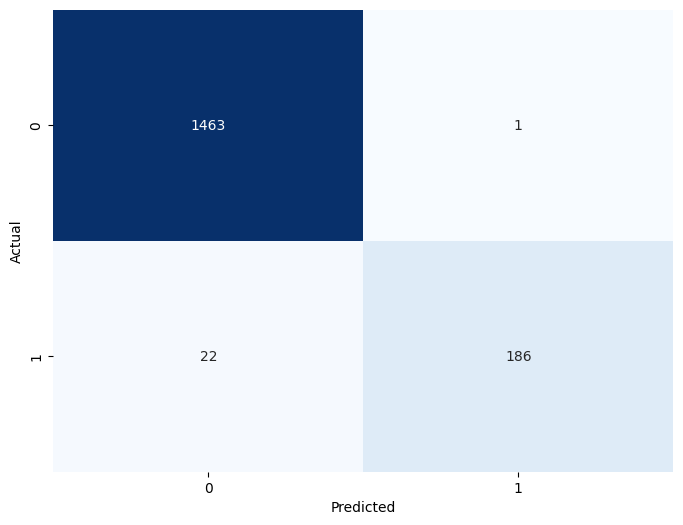

RBF (Random Search) Kernel SVM:
Best Parameters: {'C': 1000.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.1, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Accuracy: 0.9629
Classification Report:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1464
        spam       1.00      0.70      0.82       208

    accuracy                           0.96      1672
   macro avg       0.98      0.85      0.90      1672
weighted avg       0.96      0.96      0.96      1672



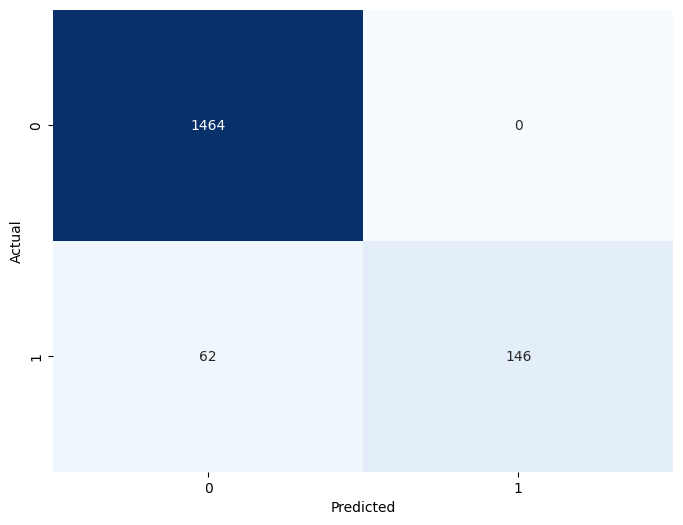

In [13]:
def evaluate_and_plot_confusion_matrix(model, X_test, y_true, y_pred, kernel_name):
    accuracy = accuracy_score(y_true, y_pred)
    conf_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred)
    
    print(f"{kernel_name} Kernel SVM:")
    print(f'Best Parameters: {model.get_params()}')
    print(f'Accuracy: {accuracy:.4f}')
    print('Classification Report:\n', class_report)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    
evaluate_and_plot_confusion_matrix(best_linear_model, X_test, y_test, y_pred_linear, "Linear (Grid Search)")
evaluate_and_plot_confusion_matrix(best_rbf_model, X_test, y_test, y_pred_rbf, "RBF (Random Search)")

In [ ]:
# End of Q7